The given code is for removing background for the grid time series seperately and joining them in to a single time series dataset and finally labelling it under a given spatial and time window

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import os
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_pickle('C:\PROJECT-DEMETER\VAE-Image\Down_Orbits-max-val-location.pkl')


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_53380\2464137446.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = pd.read_pickle('C:\PROJECT-DEMETER\VAE-Image\Down_Orbits-max-val-location.pkl')


In [4]:
import numpy as np

def create_grid(width, depth):

    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180, 180
    
    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)

    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    # Assign IDs to each grid cell
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            lat_start = min_lat + lat_idx * depth
            lat_end = lat_start + depth
            lon_start = min_lon + lon_idx * width
            lon_end = lon_start + width
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}: (({lon_start},{lon_end}),({lat_start},{lat_end}))'
            # print(lat_idx,num_lon_cells,lon_idx,lat_idx * num_lon_cells + lon_idx + 1)
            # print(grid[lat_idx, lon_idx])
    return grid

# Example usage
grid = create_grid(20, 20)
# print(grid)


In [5]:
def model_func(t, a, b, c, d, e):
    return a + t*b + c * np.sin((2*np.pi* t)/d + e)

def calculate_filtered_stats(data, column):
    mean_value = data[column].mean()
    conf_interval = stats.norm.interval(0.90, loc=mean_value, scale=np.std(data[column]))
    filtered_data = data[(data[column] >= conf_interval[0]) & (data[column] <= conf_interval[1])]
    
    if filtered_data.empty:
        filtered_data = data
    
    mean_filtered = filtered_data[column].mean()
    std_filtered = np.std(filtered_data[column]) / np.sqrt(len(filtered_data[column]))
    
    return mean_filtered, std_filtered

In [7]:
def fit_data(specific_key, min_samples, fbs,window_size, d, e):
  
    all_band_values = {}
    total_samples = sum(len(grid_data) for grid_data in data[specific_key])
    
    if total_samples <= min_samples:
        return  # Exit if total samples are insufficient

    for grid_data in data[specific_key]:
        for band_key, band_data in grid_data.items():
            if band_key == fbs: 
                if band_key in all_band_values:
                    all_band_values[band_key].append(band_data)
                else:
                    all_band_values[band_key] = [band_data]

    
    for band_key, band_values in all_band_values.items():
        # Extract datetime and Q values and convert to DataFrame
        datetime_values = [pd.to_datetime(entry['datetime']) for entry in band_values]
        q3_values = [entry['Q3'] for entry in band_values]
        lat = [entry['lat'] for entry in band_values]
        lon = [entry['lon'] for entry in band_values]

        df= pd.DataFrame({
            'datetime': datetime_values,
            f'Q3_{band_key}': q3_values,
            'lat': lat,
            'lon':lon

        })
        # print(df)

    
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)
        timestamp_data1 = pd.to_datetime(datetime_values)
        timestamp_values1 = timestamp_data1.to_numpy().astype('datetime64[s]').astype('int')
        t1 = (timestamp_values1 - timestamp_values1[0]) / (24 * 3600)  # convert to days

        # Resample the DataFrame to specified window size
        resampled_groups = df.resample(window_size)
        window_data = {window: group for window, group in resampled_groups}
       
        results = []

        for key, dat in window_data.items():
            dat = dat.dropna(subset=[f'Q3_{band_key}'])

            if not dat.empty and len(dat) >= 2:
                mean_std_results = {}
                for column in [f'Q3_{band_key}']:
                    mean_filtered, std_filtered = calculate_filtered_stats(dat, column)
                    mean_std_results[f'mean_{column}'] = mean_filtered
                    mean_std_results[f'std_{column}'] = std_filtered

                mean_std_results['window'] = key
                results.append(mean_std_results)
          
        if len(results) < 25:  # Adjust the threshold as needed
            print(f"Ignoring specific_key: {specific_key}, not enough data points after resampling")
            continue

        resampled_df = pd.DataFrame(results)
        
        # resampled_df.to_csv('test.csv')
        resampled_df.dropna(inplace=True)

        # Convert datetime index to numeric for fitting
        t_data = resampled_df['window']
        timestamp_data = pd.to_datetime(t_data)
        timestamp_values = timestamp_data.to_numpy().astype('datetime64[s]').astype('int')
        t = (timestamp_values - timestamp_values[0]) / (24 * 3600) 

      
        q3_resampled = resampled_df[f'mean_Q3_{band_key}'].values
        sigma_q3= resampled_df[f'std_Q3_{band_key}'].values

        a3 = np.mean(q3_resampled)
        b3 = (q3_resampled[-1]-q3_resampled[0])/len(q3_resampled)
        c3 = (q3_resampled.max()-q3_resampled.min())/2
     
        q3 = [a3, b3,  c3 , 365.25, np.pi] 



        lower_bounds = [-np.inf, -np.inf, 0, 365.25 ,-np.inf]
        upper_bounds = [np.inf, np.inf, 2.5, 365.2500001, np.inf]

    
        popt3, pcov3 = curve_fit(model_func, t, q3_resampled, p0=q3, sigma=sigma_q3, maxfev=650000, bounds=(lower_bounds, upper_bounds))
        a, b, c, d, e = popt3

        #Calculating the residuals

        y_fit = model_func(t1, a, b, c, d, e)

        residuals2 = q3_values - y_fit
        # Add residuals to the DataFrame
        df[f'Res_{band_key}'] = residuals2

        return df

In [8]:
df2 = []
fbs = ['fb_1', 'fb_2', 'fb_3', 'fb_4', 'fb_5', 'fb_6', 'fb_7', 'fb_8', 'fb_9', 'fb_10', 'fb_11']
for key in data.keys():
    dfs = []
    for fb in fbs:
        # print(key,fb)
        df1 = fit_data(key, 100, fb, '30D', 365.25, np.pi)
        # print(df1.shape)
        if df1 is not None and not df1.empty:
            dfs.append(df1)
    if dfs:
        df_combined = pd.concat(dfs, axis=1)
        df2.append(df_combined)

if df2:
    df_final = pd.concat(df2)
    df_final.sort_index(inplace=True)
    # print(df_final)
else:
    print("No valid data to concatenate.")

Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G4, not enough data points after resampling
Ignoring specific_key: G9, not enough data points after resampling
Ignoring specific_key: G9, not enough data points after resampling
Ignoring specific_key: G9, not enough data points after resampling
Ignoring specific_key: G9, not enough data points after resamp

c:\Users\mbabu\AppData\Local\anaconda3\envs\DL\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2244: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\mbabu\AppData\Local\anaconda3\envs\DL\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2245: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G18, not enough data points after resampling
Ignoring specific_key: G155, not enough data points after resampling
Ignoring specific_key: G155, not enough data points after resampling
Ignoring specific_key: G155, not enough data points after resampling
Ignoring specific_key: G155, not enough data 

In [9]:
df_final

,Q3_fb_1,lat,lon,Res_fb_1,Grid,Q3_fb_2,lat,lon,Res_fb_2,Grid,...,Q3_fb_10,lat,lon,Res_fb_10,Grid,Q3_fb_11,lat,lon,Res_fb_11,Grid
datetime,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:05:36.579,2.044331,67.5644,172.7907,1.825591,G144,1.022945,67.5644,172.7907,1.368797,G144,...,0.986470,67.5644,172.7907,0.946316,G144,0.913925,67.5644,172.7907,1.459624,G144
2005-01-01 00:07:39.459,0.936488,60.5094,166.5650,0.717749,G144,0.350716,60.5094,166.5650,0.696569,G144,...,0.800572,60.5094,166.5650,0.760417,G144,0.314551,60.5094,166.5650,0.860247,G144
2005-01-01 00:09:42.540,-0.004689,53.2904,162.4045,-0.223427,G144,-0.201933,53.2904,162.4045,0.143922,G144,...,-0.073968,53.2904,162.4045,-0.114124,G144,-0.356579,53.2904,162.4045,0.189116,G144
2005-01-01 00:11:45.420,-0.318414,46.0087,159.3144,0.632061,G125,-0.473562,46.0087,159.3144,0.531160,G125,...,-1.052359,46.0087,159.3144,0.728591,G125,-1.208733,46.0087,159.3144,0.800436,G125
2005-01-01 00:13:48.077,-0.632140,38.7005,156.8341,0.318336,G125,-0.669641,38.7005,156.8341,0.335089,G125,...,-1.819926,38.7005,156.8341,-0.038974,G125,-2.001766,38.7005,156.8341,0.007403,G125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-16 17:25:11.610,-0.815815,-36.9934,-123.8308,0.241911,G39,-0.944151,-36.9934,-123.8308,1.360273,G39,...,-2.478077,-36.9934,-123.8308,0.171952,G39,-2.576271,-36.9934,-123.8308,0.108145,G39
2010-12-16 17:27:14.490,-0.737384,-44.3788,-126.1590,0.320340,G39,-1.221541,-44.3788,-126.1590,1.082879,G39,...,-2.072353,-44.3788,-126.1590,0.577676,G39,-2.277357,-44.3788,-126.1590,0.407060,G39
2010-12-16 17:29:17.370,-1.011893,-51.7250,-129.0128,-0.346880,G21,-0.907815,-51.7250,-129.0128,0.924098,G21,...,-0.562918,-51.7250,-129.0128,2.308373,G21,-1.260851,-51.7250,-129.0128,1.587596,G21


In [10]:
final_df= df_final.loc[:,~df_final.columns.duplicated()]

In [11]:
final_df.to_pickle('Down_Orbits-max-val-loc-RES.pkl')

In [10]:
filtered_df = final_df[final_df.index < '2010-01-01 00:00:00']

print(filtered_df)

                          Q3_fb_1      lat       lon  Res_fb_1   Q3_fb_2  \
datetime                                                                   
2005-01-01 00:05:36.579  2.044331  67.5644  172.7907  1.825591  1.022945   
2005-01-01 00:07:39.459  0.936488  60.5094  166.5650  0.717749  0.350716   
2005-01-01 00:09:42.540 -0.004689  53.2904  162.4045 -0.223427 -0.201933   
2005-01-01 00:11:45.420 -0.318414  46.0087  159.3144  0.632061 -0.473562   
2005-01-01 00:13:48.077 -0.632140  38.7005  156.8341  0.318336 -0.669641   
...                           ...      ...       ...       ...       ...   
2009-12-31 23:07:41.925 -0.129540 -22.5641  156.3924  1.010781 -1.447643   
2009-12-31 23:09:44.805  0.086146 -29.9889  154.5759  1.226465 -1.329996   
2009-12-31 23:11:47.685 -0.207972 -37.3962  152.5481  0.169580 -1.101013   
2009-12-31 23:13:50.565 -0.364835 -44.7777  150.1869  0.012716 -0.891118   
2009-12-31 23:15:53.445  0.203793 -52.1185  147.2829 -0.753766 -0.940325   

           

In [11]:
from shapely.geometry import Point, Polygon
def create_polygon(lat, lon, width):
   
    lat_delta = width / 2
    lon_delta = width / 2
    latitudes = [lat - lat_delta, lat + lat_delta, lat + lat_delta, lat - lat_delta]
    longitudes = [lon - lon_delta, lon - lon_delta, lon + lon_delta, lon + lon_delta]

    
    polygon = Polygon(zip(longitudes, latitudes))

    return polygon

In [12]:
eq = pd.read_csv("C:\PROJECT-DEMETER\Recovery-HD\EarthQuake-Data\EQ.csv", parse_dates=['Time'])
eq['Time'] = pd.to_datetime(eq['Time']).dt.strftime('%Y-%m-%d %H:%M:%S')
eq['Time'] = pd.to_datetime(eq['Time'])

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_53380\3412976430.py:1: SyntaxWarning: invalid escape sequence '\P'
  eq = pd.read_csv("C:\PROJECT-DEMETER\Recovery-HD\EarthQuake-Data\EQ.csv", parse_dates=['Time'])


In [14]:
import pandas as pd
from datetime import timedelta


def earthquake_within_window1(ts_time,lat,lon, eq_catalog, window_days=2, width=20):
    # print(type(ts_time))
    window_start_time = ts_time - timedelta(days=window_days)
    window_end_time = ts_time 
    # eq_catalog['Formatted_Time'] = eq_catalog['Time'].dt.strftime('%Y-%m-%d %H:%M:%S')
    # print(type(eq_catalog['Time'] ))
 
    # Filter earthquakes within the time window
    time_filtered_eq = eq_catalog[(eq_catalog['Time'] >= window_start_time) & (eq_catalog['Time'] <= window_end_time)]
    # print(time_filtered_eq)
    
    polygon = create_polygon(lat, lon, width)

    loc_filtered_eq = time_filtered_eq[time_filtered_eq.apply(
        lambda row: polygon.contains(Point(row['long'], row['lat'])), axis=1
    )]

    # Check if there are any earthquakes in the filtered DataFrame
    return 1 if not loc_filtered_eq.empty else 0
   


In [15]:
# Apply the function to each row in the time series data
filtered_df['label'] = filtered_df.apply(
    lambda row: earthquake_within_window1(row.name, row['lat'],  row['lon'], eq), axis=1)


C:\Users\mbabu\AppData\Local\Temp\ipykernel_53380\1814208200.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['label'] = filtered_df.apply(


In [16]:
filtered_df

,Q3_fb_1,lat,lon,Res_fb_1,Q3_fb_2,Res_fb_2,Q3_fb_3,Res_fb_3,Q3_fb_4,Res_fb_4,...,Res_fb_7,Q3_fb_8,Res_fb_8,Q3_fb_9,Res_fb_9,Q3_fb_10,Res_fb_10,Q3_fb_11,Res_fb_11,label
datetime,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:05:36.579,2.044331,67.5644,172.7907,1.825591,1.022945,1.368797,1.471744,1.315713,1.734324,0.138380,...,0.254205,1.232212,0.235415,1.132497,0.511812,0.986470,0.946316,0.913925,1.459624,0
2005-01-01 00:07:39.459,0.936488,60.5094,166.5650,0.717749,0.350716,0.696569,0.797767,0.641737,1.653489,0.057546,...,0.131390,1.121392,0.124594,1.039005,0.418319,0.800572,0.760417,0.314551,0.860247,0
2005-01-01 00:09:42.540,-0.004689,53.2904,162.4045,-0.223427,-0.201933,0.143922,0.297729,0.141700,2.006430,0.410488,...,-0.769916,0.228925,-0.767872,0.178038,-0.442650,-0.073968,-0.114124,-0.356579,0.189116,0
2005-01-01 00:11:45.420,-0.318414,46.0087,159.3144,0.632061,-0.473562,0.531160,0.964396,0.394137,2.050502,0.858499,...,0.390411,-0.675444,0.455652,-0.820042,0.672912,-1.052359,0.728591,-1.208733,0.800436,0
2005-01-01 00:13:48.077,-0.632140,38.7005,156.8341,0.318336,-0.669641,0.335089,1.552017,0.981764,1.900750,0.708751,...,-0.226908,-1.267790,-0.136692,-1.548786,-0.055830,-1.819926,-0.038974,-2.001766,0.007403,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-12-31 23:07:41.925,-0.129540,-22.5641,156.3924,1.010781,-1.447643,0.113456,-1.739061,-0.538522,-0.937144,-0.723744,...,0.366196,-1.412088,0.633100,-1.378791,0.849784,-1.131580,1.205852,-0.986341,1.407943,0
2009-12-31 23:09:44.805,0.086146,-29.9889,154.5759,1.226465,-1.329996,0.231101,-1.563136,-0.362604,-1.553192,-1.339795,...,0.015917,-1.775242,0.269948,-1.682277,0.546300,-1.409172,0.928262,-1.363112,1.031173,0
2009-12-31 23:11:47.685,-0.207972,-37.3962,152.5481,0.169580,-1.101013,0.205657,-1.114650,0.215214,-1.552591,-0.587158,...,-1.223401,-1.934456,-1.030575,-2.117860,-0.832428,-2.096027,-0.539747,-2.043495,-0.212371,0


In [18]:
filtered_df.to_pickle('Down_Orbits-max-val-location-2T20W-co_seismic.pkl')

Text(0, 0.5, 'Frequency')

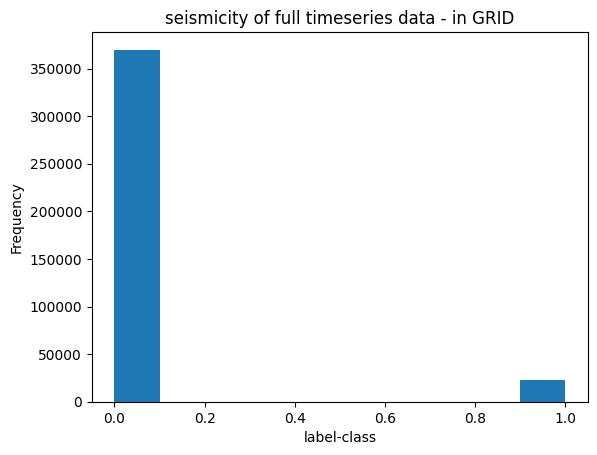

In [17]:
plt.hist(filtered_df['label'])
plt.title('seismicity of full timeseries data - in GRID')
plt.xlabel('label-class')
plt.ylabel('Frequency')

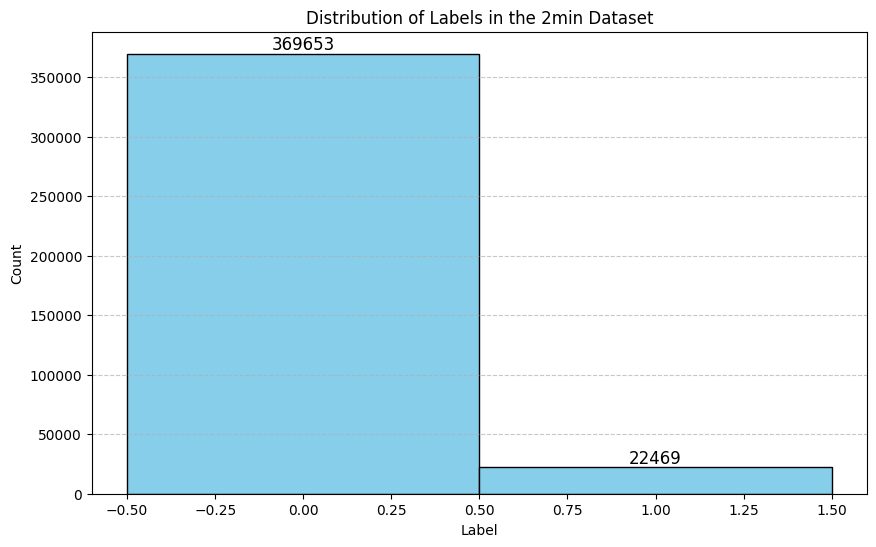

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming df_data['label'] contains the labels to be plotted
labels = filtered_df['label']

# Plot the histogram
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(labels, bins=np.arange(labels.min(), labels.max() + 2) - 0.5, edgecolor='black', color='skyblue')

# Annotate each bar with the count
for i in range(len(patches)):
    plt.text(patches[i].get_x() + patches[i].get_width() / 2, patches[i].get_height(), 
             f'{int(n[i])}', ha='center', va='bottom', fontsize=12)

# Add title and labels
plt.title('Distribution of Labels in the 2min Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()
